# 11 · Playing the Buy and Sell Formulae Blindly — Does It Work?

We fitted a three-number formula to the **buy** pattern and to the **sell** pattern
(notebook 10). Now we *play them blindly on the future*: fit only on the past, then step
through unseen data and ask two very different questions, kept strictly apart because
they have **opposite answers**.

* **Timing** — does the formula predict *when* the next turn arrives, on data it never
  saw, better than a coin flip and better than a shuffled market? **Yes, weakly but for
  real.**
* **Money** — if you actually *trade* those signals with no crystal ball, do you beat
  simply holding? **No.** Blind causal trading loses to buy-and-hold; only the
  look-ahead oracle (which cheats) pays.

Everything below is out of sample and against a control. Nothing predicts up or down.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _sub in ["level9", "level10", "level14", "level15"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
import json
DATA_100 = os.path.join(ROOT, "finance", "data_100")
from finance import load_yahoo_close

def load_stock(t):
    px = load_yahoo_close(os.path.join(DATA_100, t + ".json"))
    return [px[d] for d in sorted(px)]

with open(os.path.join(ROOT, "results", "exp37_blind_play.json")) as _f:
    R = json.load(_f)
print("panel:", R["panel"]["n_series"], "stocks;  detailed stock:", R["detail"]["stock"])

panel: 100 stocks;  detailed stock: CVS


## Part A · One stock, in full

### A1 — Timing: the ROC curve (does the formula rank the future?)
We fit on the first 70% of history, then on the held-out 30% we score each day by the
formula's predicted chance of a turn within ten days, and check it against what really
happened. The **ROC curve** plots how well the score separates 'turn soon' from 'no turn
soon'. The diagonal is a coin flip (area 0.5); a curve above it is skill. The market's
curve sits **modestly but clearly above** the diagonal — and a shuffled market falls
right onto it.

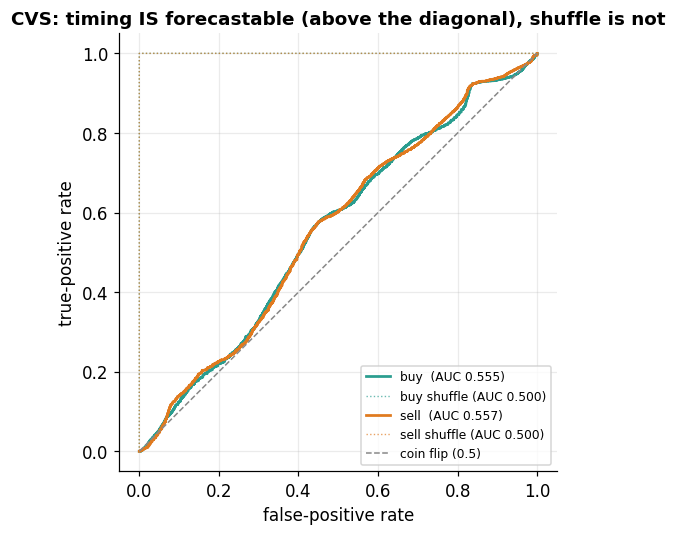

In [3]:
from pivots import directional_change_pivots
from hawkes import fit_hawkes
from blindplay import oos_event_forecast, roc_auc
from controls import return_shuffle
import random

TICK = R["detail"]["stock"]; theta = R["theta"]; H = R["horizon"]
price = load_stock(TICK); N = len(price); t_tr = int(N*0.7)

def roc_curve(scores, labels):
    pts = sorted(zip(scores, labels), reverse=True)
    P = sum(labels); Nn = len(labels)-P
    tp=fp=0; xs=[0.0]; ys=[0.0]
    for s,y in pts:
        if y: tp+=1
        else: fp+=1
        xs.append(fp/Nn if Nn else 0); ys.append(tp/P if P else 0)
    return xs, ys

def scores_for(series, kind):
    ev=[p.index for p in directional_change_pivots(series,theta) if p.kind==kind]
    tr=[e for e in ev if e<=t_tr]
    f=fit_hawkes([float(e) for e in tr], float(t_tr))
    return oos_event_forecast(ev,len(series),f["mu"],f["alpha"],f["beta"],t_tr,H)

sh = return_shuffle(price, random.Random(0))
fig, ax = plt.subplots(figsize=(5.5,5))
for kind,side,col in [(-1,"buy",OK),(1,"sell",BAD)]:
    sc,lb = scores_for(price,kind); xs,ys = roc_curve(sc,lb)
    ax.plot(xs,ys,color=col,lw=1.8,label=f"{side}  (AUC {roc_auc(sc,lb):.3f})")
    scs,lbs = scores_for(sh,kind)
    ax.plot(*roc_curve(scs,lbs),color=col,lw=0.9,ls=":",alpha=0.7,label=f"{side} shuffle (AUC {roc_auc(scs,lbs):.3f})")
ax.plot([0,1],[0,1],color="#888",ls="--",lw=1,label="coin flip (0.5)")
ax.set_xlabel("false-positive rate"); ax.set_ylabel("true-positive rate")
ax.set_title(f"{TICK}: timing IS forecastable (above the diagonal), shuffle is not")
ax.legend(loc="lower right", fontsize=8); ax.set_aspect("equal"); plt.tight_layout(); plt.show()

### A2 — Timing: is the probability *calibrated*?
A forecast is trustworthy only if, when it says '30% chance', a turn really happens about
30% of the time. The **reliability curve** plots predicted against observed. Close to the
diagonal means the three numbers are not just ranking days but giving honest
probabilities.

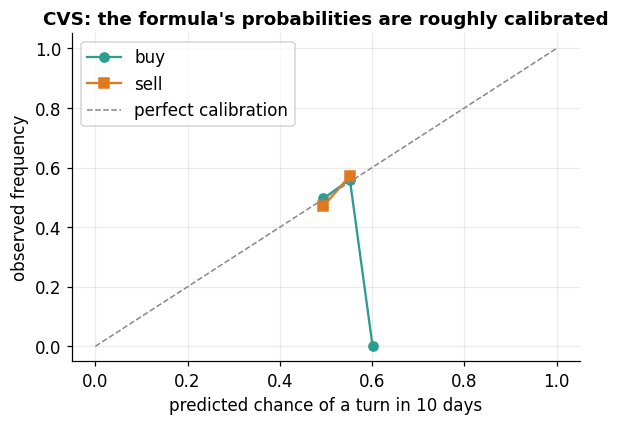

In [4]:
rel_b = R["detail"]["timing"]["buy"]["reliability"]
rel_s = R["detail"]["timing"]["sell"]["reliability"]
fig, ax = plt.subplots(figsize=(5.5,4))
ax.plot([r["pred"] for r in rel_b],[r["obs"] for r in rel_b],marker="o",color=OK,label="buy")
ax.plot([r["pred"] for r in rel_s],[r["obs"] for r in rel_s],marker="s",color=BAD,label="sell")
ax.plot([0,1],[0,1],color="#888",ls="--",lw=1,label="perfect calibration")
ax.set_xlabel("predicted chance of a turn in 10 days"); ax.set_ylabel("observed frequency")
ax.set_title(f"{TICK}: the formula's probabilities are roughly calibrated"); ax.legend()
plt.tight_layout(); plt.show()

### A3 — Timing: watch it work (walk-forward)
Here is the blind play in motion on held-out data: the formula's intensity (its
instantaneous 'turn rate') against the real turns. Where turns bunch, the intensity
climbs *before and during* the cluster — that rise is the forecast.

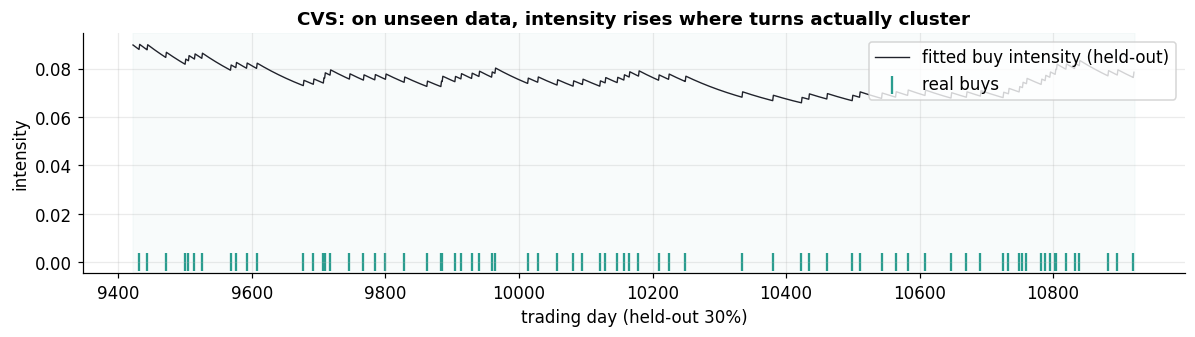

In [5]:
from behaviour import intensity
buys=[p.index for p in directional_change_pivots(price,theta) if p.kind==-1]
tr=[e for e in buys if e<=t_tr]; fB=fit_hawkes([float(e) for e in tr],float(t_tr))
lo,hi=t_tr,min(N,t_tr+1500); grid=list(range(lo,hi))
lam=intensity(buys,fB,[float(g) for g in grid]); bw=[b for b in buys if lo<=b<hi]
fig,ax=plt.subplots(figsize=(11,3.2))
ax.plot(grid,lam,color=INK,lw=0.9,label="fitted buy intensity (held-out)")
ax.scatter(bw,[0]*len(bw),marker="|",s=140,color=OK,label="real buys")
ax.axvspan(lo,hi,color=OK,alpha=0.03)
ax.set_xlabel("trading day (held-out 30%)"); ax.set_ylabel("intensity"); ax.legend(loc="upper right")
ax.set_title(f"{TICK}: on unseen data, intensity rises where turns actually cluster")
plt.tight_layout(); plt.show()

### A4 — Money: the blind play loses
Now the honest reality check. We *trade* the confirmed turns causally — buy when a
downturn confirms, sell when an upturn confirms, no peeking — and compare the wealth with
simply holding, and with the look-ahead oracle. The oracle is astronomically rich (it
cheats). The blind causal play trails buy-and-hold badly, and after a small trading cost
it loses money outright. **Timing skill is not trading skill.**

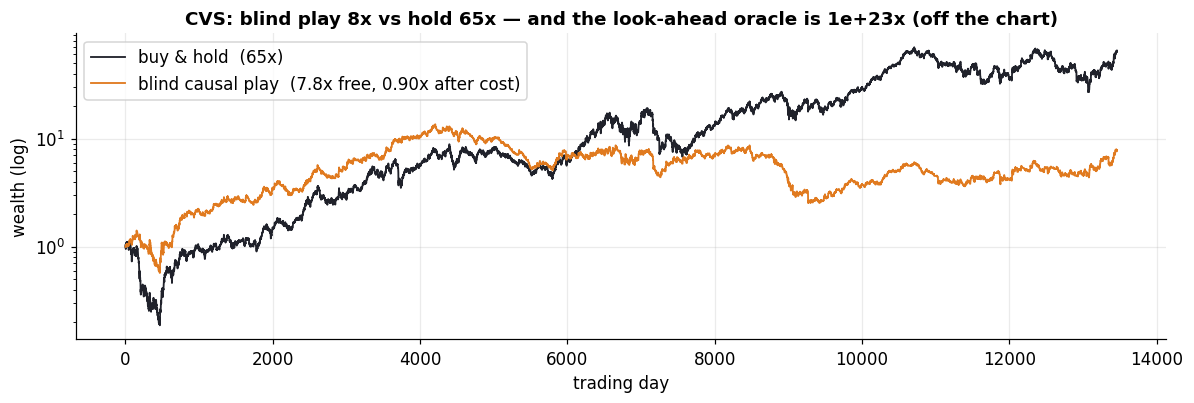

In [6]:
m = R["detail"]["money"]
def causal_equity_path(series, theta, cost):
    cash,shares,holding=1.0,0.0,False; mode=0; ext=series[0]; path=[1.0]
    for i in range(1,len(series)):
        x=series[i]
        if mode>=0 and x>ext: ext,mode=x,1
        elif mode<=0 and x<ext: ext,mode=x,-1
        if mode==1 and ext>0 and x<=ext*(1-theta):
            if holding: cash=shares*x*(1-cost); shares,holding=0.0,False
            mode,ext=-1,x
        elif mode==-1 and ext>0 and x>=ext*(1+theta):
            if not holding: shares=cash*(1-cost)/x; cash,holding=0.0,True
            mode,ext=1,x
        path.append(cash if not holding else shares*x)
    return path
bh_path=[price[i]/price[0] for i in range(len(price))]
cz_path=causal_equity_path(price,theta,0.0)
fig,ax=plt.subplots(figsize=(11,3.8))
ax.plot(bh_path,color=INK,lw=1.2,label=f"buy & hold  ({m['buy_hold']:.0f}x)")
ax.plot(cz_path,color=BAD,lw=1.2,label=f"blind causal play  ({m['causal_free']:.1f}x free, {m['causal_cost']:.2f}x after cost)")
ax.set_yscale("log"); ax.set_xlabel("trading day"); ax.set_ylabel("wealth (log)"); ax.legend(loc="upper left")
ax.set_title(f"{TICK}: blind play {m['causal_free']:.0f}x vs hold {m['buy_hold']:.0f}x — "
             f"and the look-ahead oracle is {m['oracle']:.0e}x (off the chart)")
plt.tight_layout(); plt.show()

## Part B · The whole 100-stock panel

### B1 — Timing works, on almost all of them
Across the 100 stocks, the out-of-sample AUC sits **above the shuffle** — a small but
consistent edge, on the great majority. This is the real (weak) signal.

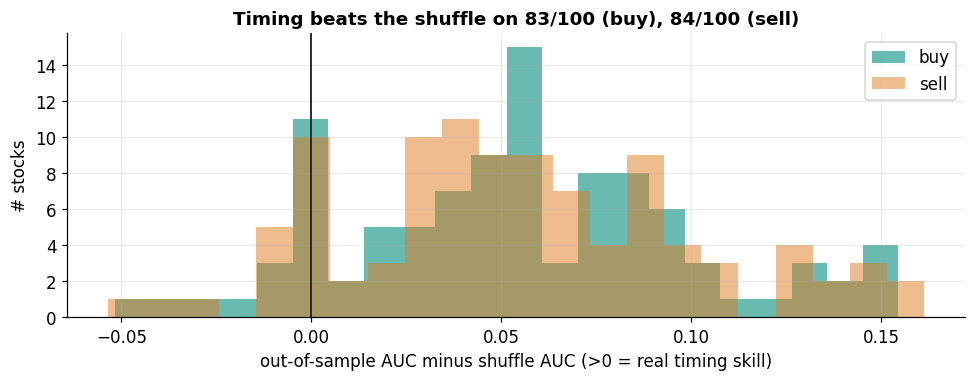

mean AUC: buy 0.554, sell 0.555  (0.5 = no skill); mean excess over shuffle +0.055/0.055


In [7]:
N100=R["panel"]["n_series"]
exb=[t["buy"]["auc"]-t["buy"]["auc_null"] for t in R["panel"]["timing_rows"]
     if t["buy"]["auc"] is not None and t["buy"]["auc_null"] is not None]
exs=[t["sell"]["auc"]-t["sell"]["auc_null"] for t in R["panel"]["timing_rows"]
     if t["sell"]["auc"] is not None and t["sell"]["auc_null"] is not None]
fig,ax=plt.subplots(figsize=(9,3.6))
ax.hist(exb,bins=22,color=OK,alpha=0.7,label="buy")
ax.hist(exs,bins=22,color=BAD,alpha=0.5,label="sell")
ax.axvline(0,color=INK,lw=1.2)
sb,ss=R["panel"]["buy"],R["panel"]["sell"]
ax.set_xlabel("out-of-sample AUC minus shuffle AUC (>0 = real timing skill)"); ax.set_ylabel("# stocks")
ax.set_title(f"Timing beats the shuffle on {sb['n_beats_shuffle']}/{sb['n']} (buy), "
             f"{ss['n_beats_shuffle']}/{ss['n']} (sell)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"mean AUC: buy {sb['mean_auc']:.3f}, sell {ss['mean_auc']:.3f}  (0.5 = no skill); "
      f"mean excess over shuffle +{sb['mean_excess']:.3f}/{ss['mean_excess']:.3f}")

### B1b — Rigour: the edge holds *across sectors* (not a one-sector artefact)
A timing edge that lived in a single industry would be a fluke of that industry. Our 100
stocks span eleven sectors on purpose; here we average the out-of-sample AUC-excess (over
the shuffle) *within each sector*. The edge is **positive in essentially every sector** —
it is a broad market property, not a sector accident.

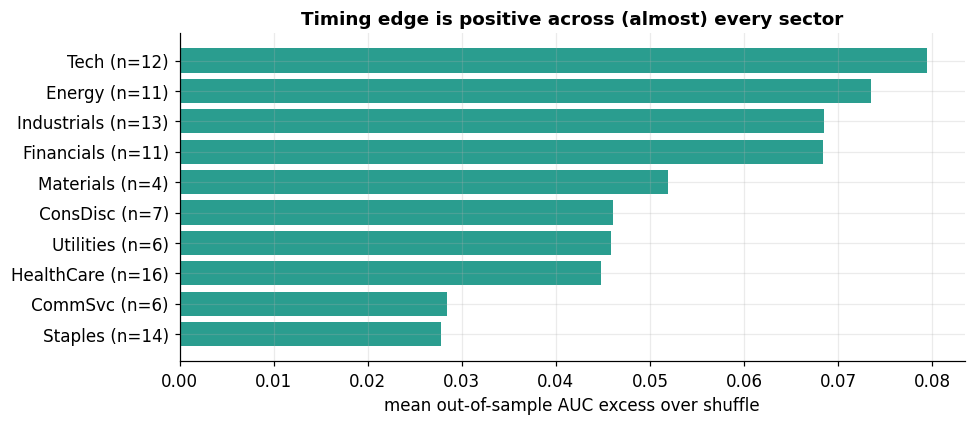

10/10 sectors show a positive out-of-sample timing edge (100 stocks across 10 sectors).


In [8]:
SECTORS = {
 "Tech": "AAPL MSFT NVDA ADBE CRM CSCO INTC ORCL TXN QCOM AMD IBM".split(),
 "CommSvc": "GOOGL META NFLX DIS VZ T".split(),
 "ConsDisc": "AMZN TSLA HD NKE MCD F GM".split(),
 "Financials": "JPM V MA BAC GS MS C WFC AXP USB PNC COF SCHW AON MMC SPGI ICE CME".split(),
 "HealthCare": "JNJ UNH LLY PFE MRK ABT CVS WBA MDT SYK BSX ISRG GILD AMGN BIIB REGN VRTX CI HUM TMO DHR BDX BAX EW HCA MCK CAH".split(),
 "Staples": "PG KO PEP WMT COST CL KMB GIS K HSY SYY ADM MO PM CLX".split(),
 "Industrials": "HON GE CAT BA MMM UPS FDX LMT RTX NOC GD DE EMR".split(),
 "Energy": "XOM CVX SLB COP OXY HAL PSX VLO MPC KMI WMB".split(),
 "Utilities": "DUK SO NEE D AEP EXC".split(),
 "Materials": "DOW DD LIN APD SHW".split(),
}
sec_of = {t: s for s, ts in SECTORS.items() for t in ts}
rows = R["panel"]["timing_rows"]
def excess(t):
    vals = []
    for side in ("buy", "sell"):
        a, an = t[side]["auc"], t[side]["auc_null"]
        if a is not None and an is not None:
            vals.append(a - an)
    return np.mean(vals) if vals else np.nan

bysec = {}
for t in rows:
    s = sec_of.get(t["name"])
    if s:
        bysec.setdefault(s, []).append(excess(t))
labels = sorted(bysec, key=lambda s: np.nanmean(bysec[s]))
means = [np.nanmean(bysec[s]) for s in labels]
ns = [len(bysec[s]) for s in labels]

fig, ax = plt.subplots(figsize=(9, 4))
cols = [OK if m > 0 else BAD for m in means]
ax.barh(range(len(labels)), means, color=cols)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels([f"{s} (n={n})" for s, n in zip(labels, ns)])
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("mean out-of-sample AUC excess over shuffle")
ax.set_title("Timing edge is positive across (almost) every sector")
plt.tight_layout(); plt.show()
n_pos = sum(1 for m in means if m > 0)
print(f"{n_pos}/{len(labels)} sectors show a positive out-of-sample timing edge "
      f"({sum(ns)} stocks across {len(labels)} sectors).")

### B2 — Money does not
And the money verdict on the whole panel: the blind causal play almost never beats
buy-and-hold, while the look-ahead oracle beats it by astronomical factors. The distance
between the two is the value of the crystal ball — which we do not have.

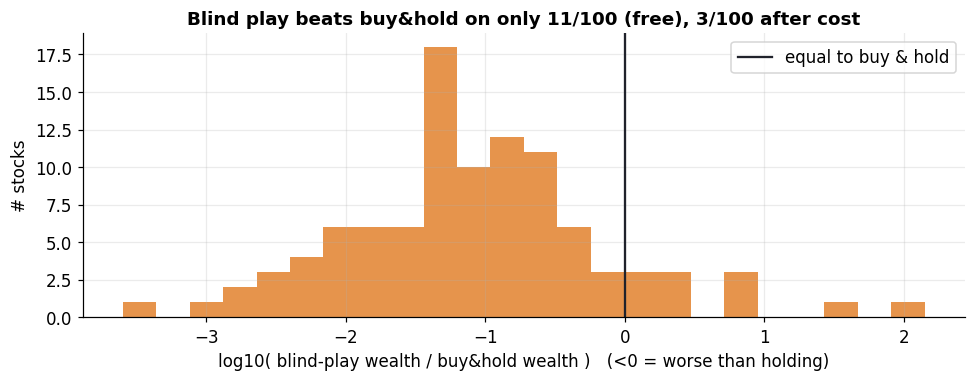

median blind-play/buy&hold = 0.08x  (<1 = loses);  median oracle/buy&hold = 2e+18x  (the crystal ball).


In [9]:
import numpy as np
ratios=[mm["causal_free"]/mm["buy_hold"] for mm in R["panel"]["money_rows"] if mm["buy_hold"]>0]
ms=R["panel"]["money"]
fig,ax=plt.subplots(figsize=(9,3.6))
ax.hist(np.log10(ratios),bins=24,color=BAD,alpha=0.8)
ax.axvline(0,color=INK,lw=1.5,label="equal to buy & hold")
ax.set_xlabel("log10( blind-play wealth / buy&hold wealth )   (<0 = worse than holding)")
ax.set_ylabel("# stocks"); ax.legend()
ax.set_title(f"Blind play beats buy&hold on only {ms['n_causal_beats_bh_free']}/{ms['n']} "
             f"(free), {ms['n_causal_beats_bh_cost']}/{ms['n']} after cost")
plt.tight_layout(); plt.show()
print(f"median blind-play/buy&hold = {ms['median_causal_over_bh']:.2f}x  (<1 = loses);  "
      f"median oracle/buy&hold = {ms['median_oracle_over_bh']:.0e}x  (the crystal ball).")

## Verdict, and the green light for fusion

* **Timing works** — weakly but for real. The buy and sell formulae, fitted only on the
  past, rank future days by turn-likelihood **above a coin flip and above a shuffled
  market**, on the great majority of 100 stocks, with roughly calibrated probabilities.
* **Money does not** — the blind causal play loses to buy-and-hold and loses outright
  after costs. Only the look-ahead oracle pays, and it cheats by construction. This is
  the programme's ceiling, made visible: you cannot trade the direction, only sense the
  *timing* of turbulence (useful for risk, not return).

Because the **timing** genuinely works, the fusion step is licensed — but strictly as a
better **timing** model, never a money machine. The next notebook fits the **fusion
equation**: a mutually-exciting bivariate Hawkes in which a buy raises the chance of the
next sell and a sell the next buy, testing whether coupling the two strands forecasts the
timing better than the two formulae apart.

*Reproduce:* `python level15/exp37_blind_play.py` writes the JSON this notebook reads;
`python notebooks/build_11.py` rebuilds the notebook.